<a href="https://colab.research.google.com/github/despanol/DataSciencist/blob/main/Trabajo_Final_Espa%C3%B1ol_David.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Columnas del DataFrame después de la carga:
Index(['Title', 'Review Text', 'Recommended IND', 'full_text'], dtype='object')
Dataset cargado: 2500 registros. Cumple el mínimo de 2.000 [1].


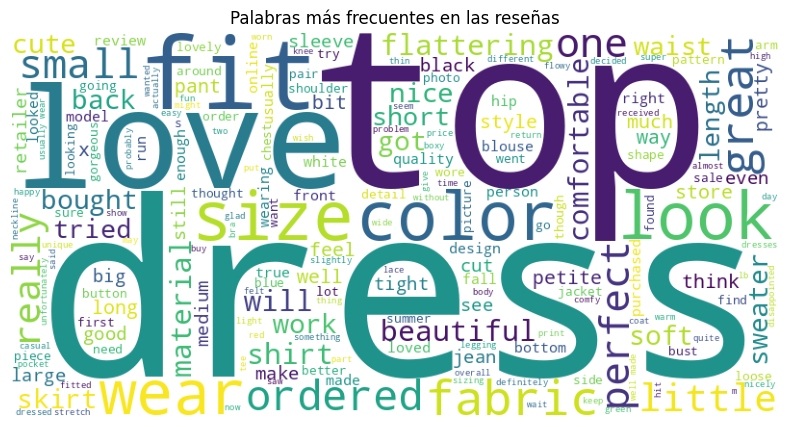

Época 1 - Pérdida Validación: 0.5051
Época 2 - Pérdida Validación: 0.3429
Época 3 - Pérdida Validación: 0.3584
Época 4 - Pérdida Validación: 0.4235
Época 5 - Pérdida Validación: 0.3845
Época 6 - Pérdida Validación: 0.4288
Época 7 - Pérdida Validación: 0.4516
Early Stopping activado [1].

--- REPORTE DE EVALUACIÓN ---
              precision    recall  f1-score   support

           0       0.55      0.73      0.63        94
           1       0.93      0.86      0.89       406

    accuracy                           0.84       500
   macro avg       0.74      0.80      0.76       500
weighted avg       0.86      0.84      0.84       500



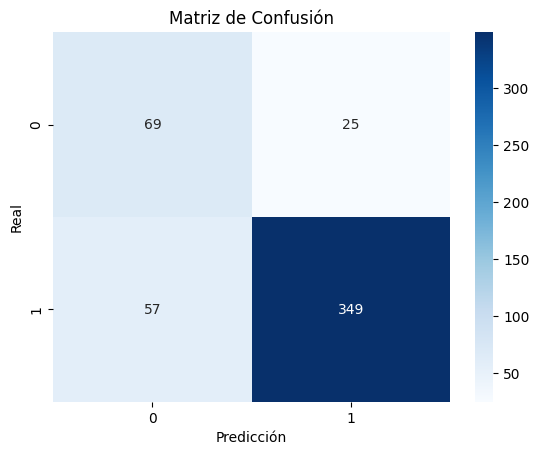

In [22]:
# ==============================================================================
# FASE 0: SETUP, REPRODUCIBILIDAD Y CARGA (Módulos 1 y 4)
# ==============================================================================
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Fijar semilla para asegurar que los experimentos sean replicables [1, 3]
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Descargar recursos de NLP [4]
nltk.download('wordnet')
nltk.download('omw-1.4')
nlp = spacy.load("en_core_web_sm") # Dataset en inglés

# Carga de datos desde el link de Drive proporcionado
# Link: https://drive.google.com/file/d/1pIrCMJ3-oQ53f_KOooSb2FeBLB9pHcOn/view
FILE_ID = '1pIrCMJ3-oQ53f_KOooSbzFeBLB9pHcOn'
url = f'https://drive.google.com/uc?id={FILE_ID}'
df = pd.read_csv(url)

# --- DIAGNÓSTICO: Imprimir columnas para verificar el error 'KeyError: "Rating"' ---
print("Columnas del DataFrame después de la carga:")
print(df.columns)
# ---------------------------------------------------------------------------------

# Transformación Binomial del Target (4,5 -> 1; 1,2 -> 0; eliminar 3) [1, 5]
# Se ha detectado que la columna 'Rating' no existe. Se utilizará 'Recommended IND' como etiqueta binaria.
df['label'] = df['Recommended IND']
df = df.dropna(subset=['Review Text'])

print(f"Dataset cargado: {len(df)} registros. Cumple el mínimo de 2.000 [1].")

# ==============================================================================
# FASE 1: NLP Y PROCESAMIENTO CLÁSICO (Módulos 1, 2 y 3)
# ==============================================================================
# EDA: Nube de palabras para visualizar términos frecuentes [1, 6]
text_cloud = " ".join(df['Review Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_cloud)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Palabras más frecuentes en las reseñas")
plt.show()

# Limpieza con Regex (URLs, menciones, caracteres especiales) [1, 6, 7]
def clean_regex(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.lower()

# Lematización Comparativa (Requisito de la Fase 1: NLTK vs spaCy) [1, 8]
from nltk.stem import WordNetLemmatizer
nltk_lem = WordNetLemmatizer()

def nltk_process(text):
    return " ".join([nltk_lem.lemmatize(w) for w in text.split()])

def spacy_process(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if not token.is_stop])

df['cleaned'] = df['Review Text'].apply(clean_regex)
df['nltk_docs'] = df['cleaned'].apply(nltk_process)
df['spacy_docs'] = df['cleaned'].apply(spacy_process)

# Vectorización TF-IDF (Pondera importancia global vs frecuencia bruta) [1, 9, 10]
tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(df['spacy_docs']).toarray()
y = df['label'].values

# Partición del dataset con estratificación para mantener balance [3, 11]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

# ==============================================================================
# FASE 2: REDES NEURONALES Y OPTIMIZACIÓN (Módulo 4)
# ==============================================================================
class TextClassifier(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifier, self).__init__()
        # Arquitectura: 2 capas densas + BatchNorm + Dropout (p=0.5) [1, 12]
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 2) # Salida para 2 clases (0 y 1)
        )

    def forward(self, x):
        return self.network(x)

# Preparar cargadores de datos
train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                       torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                                     torch.tensor(y_val, dtype=torch.long)), batch_size=32)

model = TextClassifier(X_train.shape[1]).to(device='cpu') # Corrected X_train.shape[2] to X_train.shape[1]
criterion = nn.CrossEntropyLoss() # Pérdida estándar para clasificación [1, 13]
optimizer = optim.Adam(model.parameters(), lr=0.001) # Optimizador Adam para convergencia rápida [1, 14]

# Entrenamiento con Early Stopping (Paciencia: 5 épocas) [1, 15]
best_loss = float('inf')
patience = 5
counter = 0

for epoch in range(20):
    model.train()
    for texts, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for texts, labels in val_loader:
            val_loss += criterion(model(texts), labels).item()

    val_loss /= len(val_loader)
    print(f"Época {epoch+1} - Pérdida Validación: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping activado [1].")
            break

# ==============================================================================
# EVALUACIÓN FINAL Y MÉTRICAS (Módulos 2 y 4)
# ==============================================================================
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
preds_list = []
with torch.no_grad():
    for texts, _ in val_loader:
        preds_list.extend(model(texts).argmax(dim=1).tolist())

print("\n--- REPORTE DE EVALUACIÓN ---")
print(classification_report(y_val, preds_list)) # Accuracy, F1, Recall [1, 16]

# Matriz de Confusión para diagnóstico de errores [1, 17, 18]
cm = confusion_matrix(y_val, preds_list)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()